In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=200, centers=3, cluster_std=1.5, random_state=42
)

plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [ ]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=55)
y_pred = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=y_pred)
plt.show()

In [ ]:
# 1. 초기중심 : 처음 중심을 랜덤으로 선택
k = 3
np.random.seed(42)
indices = np.random.choice(len(X), k, replace=True)
centroids = X[indices]

plt.scatter(X[:,0], X[:,1])
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)
plt.show()

In [ ]:
# 2. 각 점을 가장 가까운 중심에 할당
# 거리계산 -> 가장 가까운 중심 선택

def assign_cluster(X, centroids):
    distance = np.linalg.norm(X[:,np.newaxis] - centroids, axis=2)
    return np.argmin(distance, axis=1)

label = assign_cluster(X, centroids)

plt.scatter(X[:,0], X[:,1], c=label)
plt.show()

In [ ]:
# 3. 중심이동
# 각 그룹의 평균을 계산  ->  새로운 중심

def update_centroid(X, label, k):
    return np.array( [X[label == i].mean(axis=0) for i in range(k)] )
centroids = update_centroid(X, label, k)

# 새로운 중심점을 좌표에 업데이트
# 새로운 중심점을 기준으로 라벨 분리해서 시각화

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X[:,0], X[:,1])
ax[0].scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)

label = assign_cluster(X, centroids)
ax[1].scatter(X[:,0], X[:,1], c=label)

plt.show()

# 이 모델의 문제점 : 반복 없음

In [ ]:
def kmeans(X, k, max_iter=100):
    # 초기 중심 랜덤 선택
    centroids = X[np.random.choice(len(X), k, replace=True)]

    for _ in range(max_iter):
        # 1. 클러스터 할당
        labels = assign_cluster(X, centroids)

        # 2. 중심 업데이트
        new_centroids = update_centroid(X, labels, k)

        # 3. 수렴 체크
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return centroids, labels

In [ ]:
centroids, labels = kmeans(X, k=3)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)
plt.show()

In [ ]:
# 최적의 k 개수 -> 엘보우
# k 증가할수록 오차는 감소 WCSS
# 어느순간 감소폭이 급격히 줄어듬 -> 그 지점

k_range = range(1,11)
wcss = []
for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(k_range, wcss, marker='o')
plt.show()

In [ ]:
# 실루엣 스코어
# 같은 클러스터 끼리는 가깝고 다른 클러스터와는 멀어야 좋다 ( 1 ~ -1 )
from sklearn.metrics import silhouette_score

scores =  []
k_range = range(2,11)
for i in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

np.argmax(scores) + 2

In [13]:
# 와인 데이터 정답 제거 -> kmeans로 클러스터 분리 -> 최적의 k 찾기

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine(as_frame=True)
x = wine.data
y = wine.target

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

k_range = range(2,11)
scores = []
inertia_results = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    inertia = model.inertia_

    scores.append((k, score))
    inertia_results.append((k, inertia))
    print(f'k={k}, silhouette={score:.4f}')

best_k, best_score = max(scores, key=lambda t: t[1])
print(f'best_k:{best_k}, best_score:{best_score}')
print(f'inertia list: {inertia_results}')

k=2, silhouette=0.2650
k=3, silhouette=0.2849
k=4, silhouette=0.2542
k=5, silhouette=0.1836
k=6, silhouette=0.1690
k=7, silhouette=0.1726
k=8, silhouette=0.1625
k=9, silhouette=0.1739
k=10, silhouette=0.1396
best_k:3, best_score:0.2848589191898987
inertia list: [(2, 1661.6761165626506), (3, 1277.928488844642), (4, 1211.7531134671585), (5, 1123.1565470796963), (6, 1079.5385091588262), (7, 1014.4309086924652), (8, 982.65497629377), (9, 927.9560760726212), (10, 879.4257007542494)]


c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\env

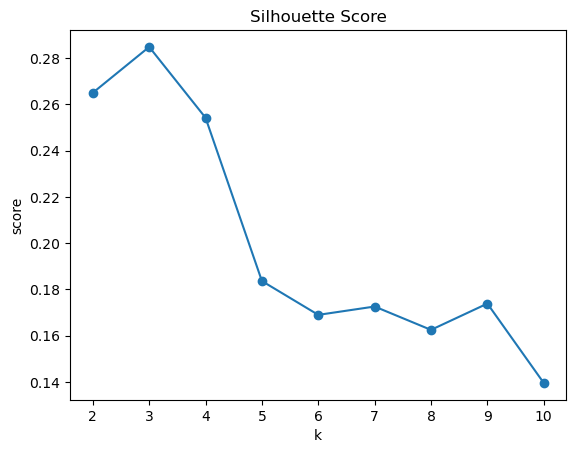

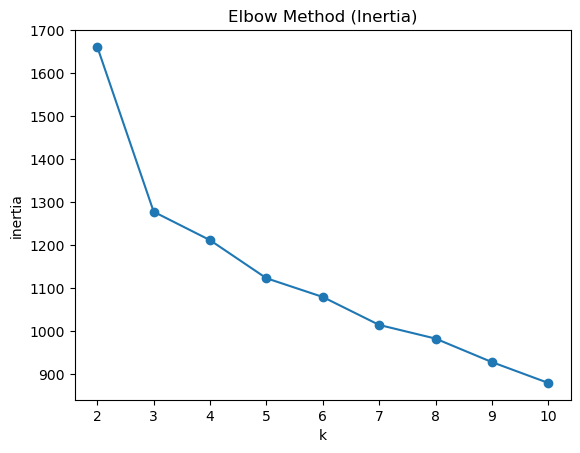

In [14]:
import matplotlib.pyplot as plt

k_vals = [k for k, _ in scores]
score_vals = [s for _, s in scores]
inertia_vals = [i for _, i in inertia_results]

plt.figure()
plt.plot(k_vals, score_vals, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("score")
plt.show()

plt.figure()
plt.plot(k_vals, inertia_vals, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.show()

In [17]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y, labels)
row_ind, col_ind = linear_sum_assignment(-cm)

acc = cm[row_ind, col_ind].sum() / np.sum(cm)
print("최적 매칭 정확도:", acc)

최적 매칭 정확도: 0.4943820224719101


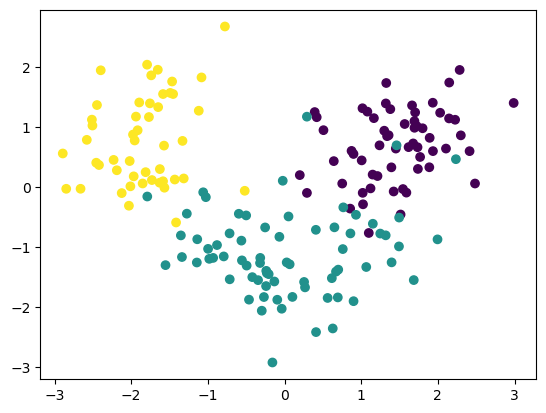

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    (RobustScaler()),
    (PCA(n_components=2))
)
x_preprocessing = pipeline.fit_transform(x)

plt.scatter(x_preprocessing[:,0], x_preprocessing[:,1], c=y)
plt.show()